# ⚽ Global Football Transfer Market Analysis & Prediction

**Dataset:** Top 100 transfers by fee per season, 2000-01 to 2025-26 (~2,600 records)

This notebook walks through a complete data science workflow:
1. **Data Audit & Cleaning** - fix what the raw CSV gets wrong
2. **Exploratory Data Analysis (EDA)** - find patterns visually before modelling
3. **Feature Engineering** - translate football knowledge into numbers a model can use
4. **Machine Learning** - build a Random Forest regressor and interpret its results

Run cells from top to bottom. All outputs (charts, CSVs, model scores) are generated in sequence.

---
## Setup — Import All Libraries

All libraries are loaded once here. Every cell below can use `pd`, `np`, `plt`, `sns`, and `sklearn` without re-importing.

| Library | Alias | What it does |
|---|---|---|
| pandas | `pd` | Loads and manipulates tabular data (the DataFrame) |
| numpy | `np` | Array-level math; used here mainly for `log1p()` |
| matplotlib.pyplot | `plt` | Low-level chart engine — canvas, axes, titles |
| seaborn | `sns` | High-level statistical charts built on top of matplotlib |
| scikit-learn | `sklearn` | Train/test split, Random Forest model, R² metric |

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Global chart style — applies to every plot in this notebook
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## Phase 1 — Data Audit & Cleaning

**Goal:** Understand exactly what the raw CSV contains and fix the two things that would break all downstream analysis:
1. An unnamed column that needs a proper label
2. The `Season` column stored as text (`"2000-2001"`) instead of a usable number

No analysis happens here — this phase is purely about trust: can you rely on every value in the DataFrame to mean what you think it means?

### 1.1 Load the Raw Data and Audit It

`.shape` tells you rows × columns. `.info()` tells you the data type of each column and how many non-null values exist. Run these before anything else — they reveal whether fees were read as numbers or text, and which columns have missing data.

In [5]:
# Load raw CSV
df = pd.read_csv("../data/global_football_transfer_dataset.csv")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
df.info()

Shape: 2,600 rows × 11 columns

<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Season       2600 non-null   str  
 1   Player       2600 non-null   str  
 2   Position     2600 non-null   str  
 3   Age          2600 non-null   int64
 4   Nationality  2600 non-null   str  
 5   From_League  2600 non-null   str  
 6   From_Club    2600 non-null   str  
 7   To_League    2600 non-null   str  
 8   To_Club      2600 non-null   str  
 9   Fee_Euros    2600 non-null   int64
 10  Unnamed: 10  7 non-null      str  
dtypes: int64(2), str(9)
memory usage: 223.6 KB


### 1.2 Preview the First Few Rows

`.head()` shows the first 5 rows. Use this to visually confirm that column names match what you expect and values look sensible.

In [6]:
df.head()

,Season,Player,Position,Age,Nationality,From_League,From_Club,To_League,To_Club,Fee_Euros,Unnamed: 10
0,2000-2001,Luís Figo,Right Winger,27,Portugal,LaLiga,Barcelona,LaLiga,Real Madrid,60000000,NaN
1,2000-2001,Hernán Crespo,Centre-Forward,25,Argentina,Serie A,Parma Calcio 1913,Serie A,Lazio,56810000,NaN
2,2000-2001,Gabriel Batistuta,Centre-Forward,31,Argentina,Serie A,Fiorentina,Serie A,AS Roma,36150000,NaN
3,2000-2001,Nicolas Anelka,Centre-Forward,21,France,LaLiga,Real Madrid,Ligue 1,PSG,34500000,NaN
4,2000-2001,Marc Overmars,Left Winger,27,Netherlands,Premier League,Arsenal,LaLiga,Barcelona,29300000,NaN


### 1.3 Check for Missing Values

`.isnull().sum()` counts nulls per column. A null `Fee_Euros` is not random noise — it likely means the transfer fee was undisclosed, which is structurally different from "data not collected." Worth knowing before you decide how to handle it.

In [7]:
null_counts = df.isnull().sum()
print("Null values per column:")
print(null_counts[null_counts > 0] if null_counts.any() else "No nulls found.")

Null values per column:
Unnamed: 10    2593
dtype: int64


### 1.4 Clean: Rename the Unnamed Column and Parse the Season

**Unnamed column:** The raw CSV has a trailing comma on every row, which causes pandas to create a column with no header. It contains sparse loan fee data. We rename it rather than drop it — don't discard data you haven't fully understood yet.

**Season parsing:** `"2000-2001"` is a string. Python cannot do arithmetic on strings. We split it at the hyphen and extract the start year as an integer. This single step unlocks every time-based chart and the inflation-adjustment calculation in Phase 3.

`inplace=True` on `.rename()` means "modify this DataFrame directly" rather than returning a new one.

In [8]:
# Rename the unnamed trailing column
df.rename(columns={"Unnamed: 10": "Loan_Fee"}, inplace=True)

# Split "2000-2001" → Start_Year=2000, End_Year=2001
years = df["Season"].str.split("-", expand=True)
df["Start_Year"] = years[0].astype(int)
df["End_Year"]   = years[1].astype(int)

# Save the processed file for use in later phases
df.to_csv("../data/processed_transfer_data.csv", index=False)

print("Cleaning complete.")
print(f"Columns now: {list(df.columns)}")
df[["Season", "Start_Year", "End_Year", "Fee_Euros", "Loan_Fee"]].head()

Cleaning complete.
Columns now: ['Season', 'Player', 'Position', 'Age', 'Nationality', 'From_League', 'From_Club', 'To_League', 'To_Club', 'Fee_Euros', 'Loan_Fee', 'Start_Year', 'End_Year']


,Season,Start_Year,End_Year,Fee_Euros,Loan_Fee
0,2000-2001,2000,2001,60000000,NaN
1,2000-2001,2000,2001,56810000,NaN
2,2000-2001,2000,2001,36150000,NaN
3,2000-2001,2000,2001,34500000,NaN
4,2000-2001,2000,2001,29300000,NaN


---
## Phase 2 — Exploratory Data Analysis (EDA)

**Goal:** Find patterns *before* making assumptions. Every chart here is asking a question about the data. The answers will directly determine which machine learning model we choose and which features we build.

EDA questions this phase answers:
- What shape is the fee distribution? (determines whether we need a log transform)
- Has fee inflation been uniform, or concentrated at the top? (mean vs median divergence)
- Does age predict fee in a straight line? (determines whether linear regression is viable)
- Which leagues spend the most? (validates league rank as a feature)
- Do attacking positions command a premium?
- Are international transfers systematically more expensive?

### 2.1 Fee Distribution — Raw vs. Log-Transformed

**What to look for:** The raw histogram will be heavily right-skewed — most transfers cluster in a low range, with a thin tail of extreme outliers (Neymar, Mbappé, etc.). This shape breaks most statistical tools and confuses ML models because the outliers dominate the calculations.

`np.log1p(x)` applies log(1 + x). The "+1" safely handles any zero values. After transformation, the distribution should approximate a bell curve — a prerequisite for well-behaved regression.

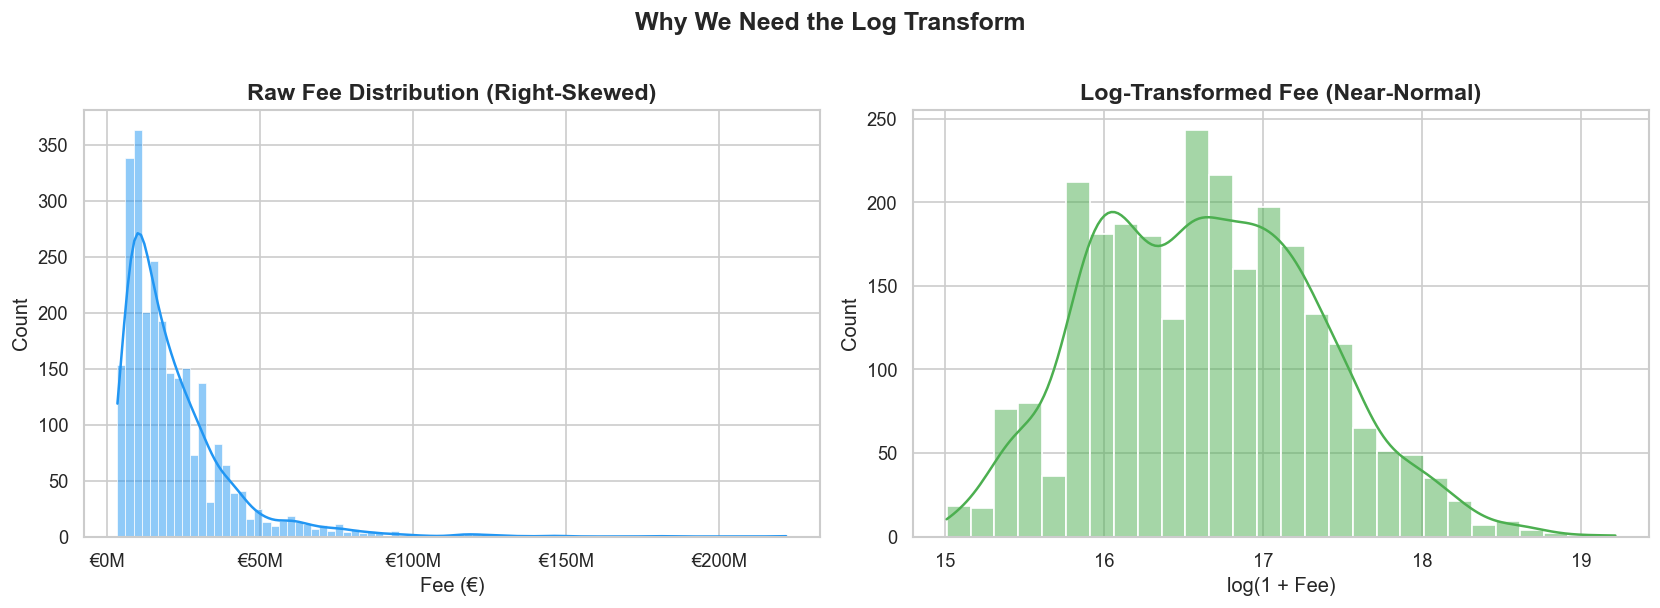

Skewness — Raw: 2.86  |  Log-transformed: 0.23
(Closer to 0 = more symmetrical. Target is roughly -1 to +1)


In [9]:
df = pd.read_csv("../data/processed_transfer_data.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw distribution
sns.histplot(df["Fee_Euros"], kde=True, ax=ax1, color="#2196F3")
ax1.set_title("Raw Fee Distribution (Right-Skewed)")
ax1.set_xlabel("Fee (€)")
ax1.set_ylabel("Count")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1e6:.0f}M"))

# Right: log-transformed
sns.histplot(np.log1p(df["Fee_Euros"]), kde=True, ax=ax2, color="#4CAF50")
ax2.set_title("Log-Transformed Fee (Near-Normal)")
ax2.set_xlabel("log(1 + Fee)")
ax2.set_ylabel("Count")

plt.suptitle("Why We Need the Log Transform", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../images/01_fee_distribution.png", bbox_inches="tight")
plt.show()

skew_raw = df["Fee_Euros"].skew()
skew_log = np.log1p(df["Fee_Euros"]).skew()
print(f"Skewness — Raw: {skew_raw:.2f}  |  Log-transformed: {skew_log:.2f}")
print("(Closer to 0 = more symmetrical. Target is roughly -1 to +1)")

### 2.2 Transfer Fee Inflation — Mean vs. Median (2000–2025)

**What to look for:** Two lines on one chart. If the market is inflating uniformly, mean and median should track each other closely. If they diverge — mean shooting up while median rises slowly — it means a small number of elite transfers are growing exponentially while the average deal stays relatively stable.

This is the "Superstar Effect" made quantitatively visible. The year the lines separate is when the market structurally bifurcated.

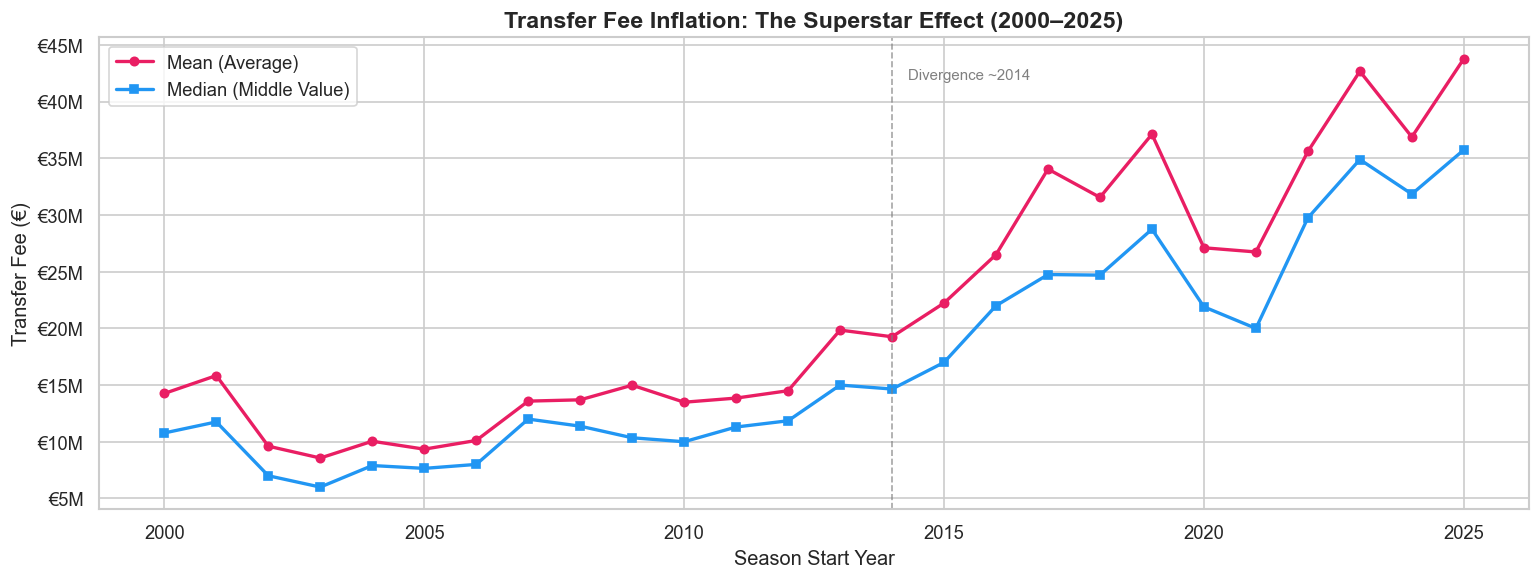

Mean / Median ratio in recent seasons (higher = more top-heavy market):
 Start_Year       Mean     Median  Mean/Median Ratio
       2000 14260200.0 10775000.0               1.32
       2001 15838500.0 11750000.0               1.35
       2002  9609800.0  7000000.0               1.37
       2003  8563500.0  6000000.0               1.43
       2004 10045600.0  7900000.0               1.27
       2005  9345400.0  7650000.0               1.22
       2006 10112300.0  8000000.0               1.26
       2007 13584100.0 12000000.0               1.13
       2008 13698400.0 11375000.0               1.20
       2009 14987000.0 10350000.0               1.45
       2010 13487100.0 10000000.0               1.35
       2011 13851000.0 11300000.0               1.23
       2012 14501800.0 11850000.0               1.22
       2013 19850300.0 15000000.0               1.32
       2014 19261700.0 14650000.0               1.31
       2015 22235500.0 17000000.0               1.31
       2016 26507700.0 2200

In [12]:
inflation_df = (
    df.groupby("Start_Year")["Fee_Euros"]
    .agg(Mean="mean", Median="median")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(inflation_df["Start_Year"], inflation_df["Mean"],
        marker="o", markersize=5, linewidth=2, label="Mean (Average)", color="#E91E63")
ax.plot(inflation_df["Start_Year"], inflation_df["Median"],
        marker="s", markersize=5, linewidth=2, label="Median (Middle Value)", color="#2196F3")

# Annotate the divergence point
ax.axvline(x=2014, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.text(2014.3, ax.get_ylim()[1] * 0.92, "Divergence ~2014", fontsize=9, color="grey")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1e6:.0f}M"))
ax.set_title("Transfer Fee Inflation: The Superstar Effect (2000–2025)")
ax.set_xlabel("Season Start Year")
ax.set_ylabel("Transfer Fee (€)")
ax.legend()

plt.tight_layout()
plt.savefig("../images/02_inflation_mean_vs_median.png", bbox_inches="tight")
plt.show()

# Print the divergence ratio in the final 5 seasons
last5 = inflation_df.copy()
last5["Mean/Median Ratio"] = (last5["Mean"] / last5["Median"]).round(2)
print("Mean / Median ratio in recent seasons (higher = more top-heavy market):")
print(last5[["Start_Year", "Mean", "Median", "Mean/Median Ratio"]].to_string(index=False))

### 2.3 Age vs. Transfer Fee — The Age Paradox

**What to look for:** If age predicted fee in a straight line, the regression line would slope clearly upward or downward. A flat line means no linear relationship. This finding directly rules out linear regression as a modelling approach — a non-linear model is needed.

The scatter of dots also tells its own story: teenage "wonderkids" appear at very high prices, because clubs are buying future potential and resale value rather than current ability.

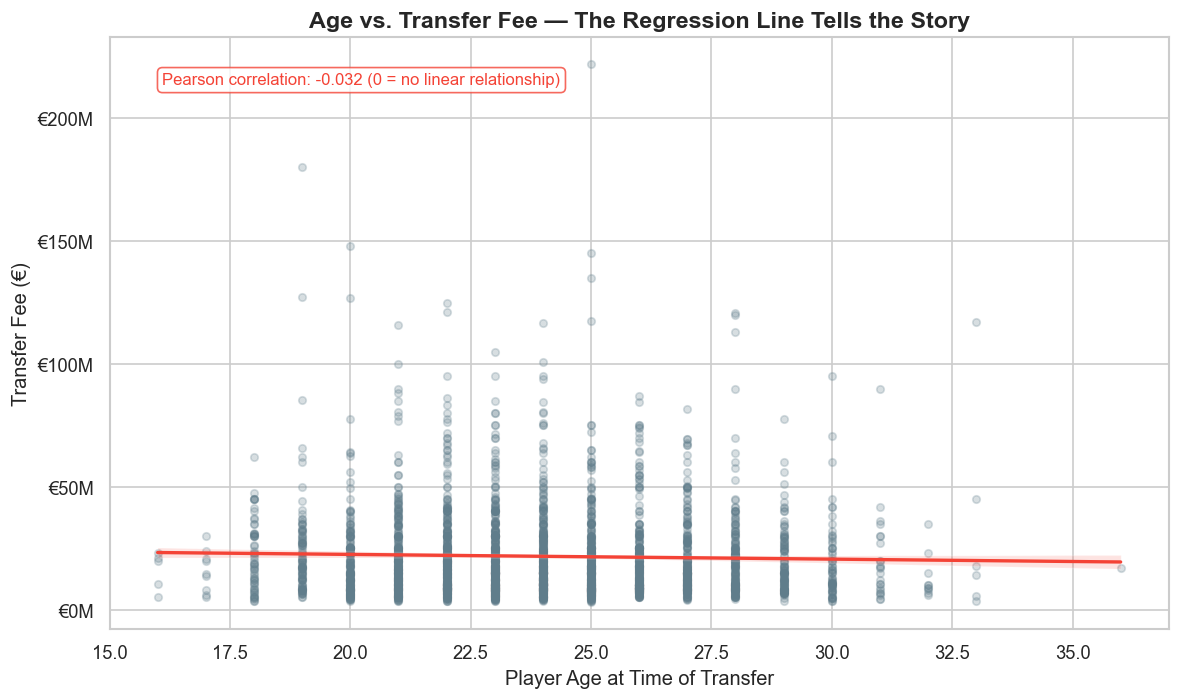

Pearson correlation (Age vs Fee_Euros): -0.0322
Interpretation: Near-zero — no linear relationship exists between age and fee.


In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=df, x="Age", y="Fee_Euros",
    scatter_kws={"alpha": 0.25, "s": 20, "color": "#607D8B"},
    line_kws={"color": "#F44336", "linewidth": 2},
    ax=ax
)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1e6:.0f}M"))
ax.set_title("Age vs. Transfer Fee — The Regression Line Tells the Story")
ax.set_xlabel("Player Age at Time of Transfer")
ax.set_ylabel("Transfer Fee (€)")

# Annotate correlation value
corr = df["Age"].corr(df["Fee_Euros"])
ax.annotate(
    f"Pearson correlation: {corr:.3f} (0 = no linear relationship)",
    xy=(0.05, 0.92), xycoords="axes fraction",
    fontsize=10, color="#F44336",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#F44336", alpha=0.8)
)

plt.tight_layout()
plt.savefig("../images/03_age_vs_fee.png", bbox_inches="tight")
plt.show()

print(f"Pearson correlation (Age vs Fee_Euros): {corr:.4f}")
print("Interpretation: Near-zero — no linear relationship exists between age and fee.")

### 2.4 Top 15 Destination Leagues by Average Transfer Fee

**What to look for:** The wealth gap between the top leagues and the rest. This chart justifies using `To_League_Rank` as an ML feature — the destination league is a strong structural signal of price. A player moving to a league that routinely pays €40M+ commands a very different baseline than one moving to a league averaging €5M.

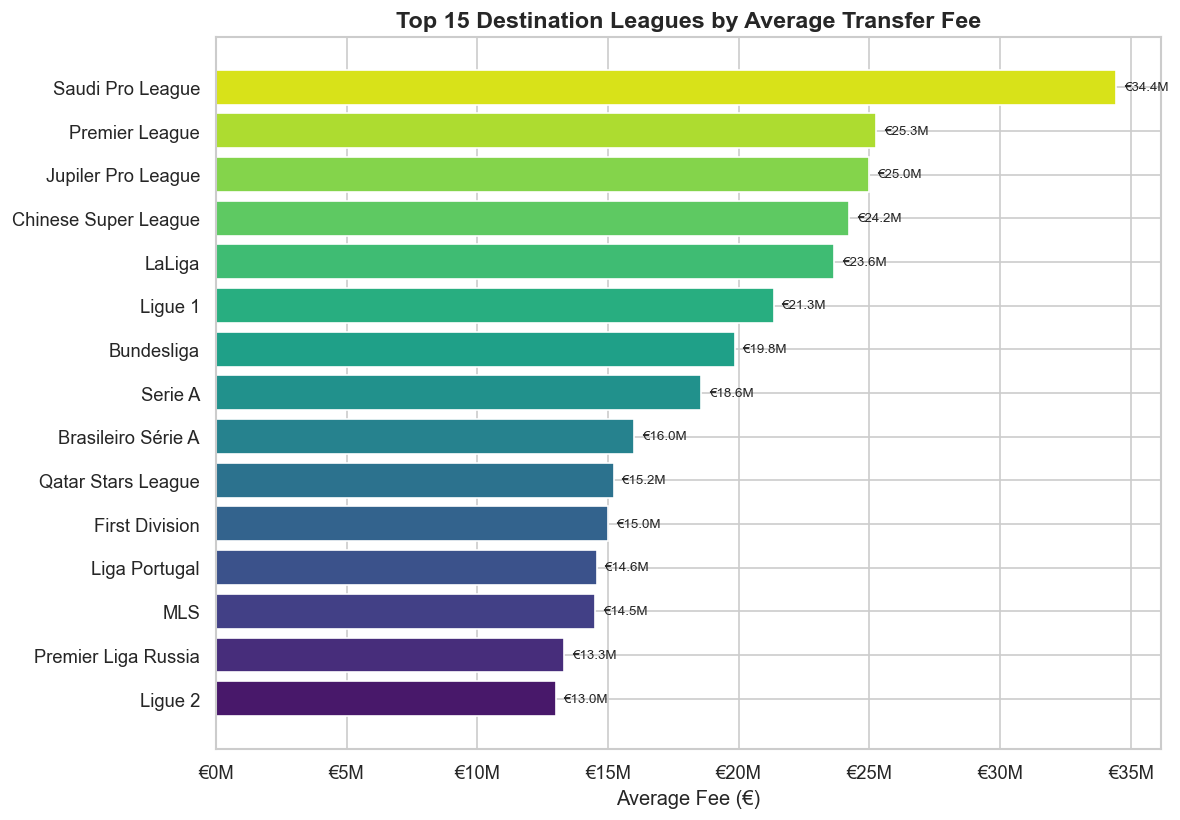

In [21]:
top_leagues = (
    df.groupby("To_League")["Fee_Euros"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(top_leagues.index[::-1], top_leagues.values[::-1],
               color=sns.color_palette("viridis", len(top_leagues)))

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1e6:.0f}M"))
ax.set_title("Top 15 Destination Leagues by Average Transfer Fee")
ax.set_xlabel("Average Fee (€)")
ax.set_ylabel("")

# Value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3e6, bar.get_y() + bar.get_height()/2,
            f"€{width/1e6:.1f}M", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../images/04_top_leagues_avg_fee.png", bbox_inches="tight")
plt.show()

### 2.5 Correlation Matrix — Age, Year, and Fee

**What to look for:** Two numbers decide what kind of model to build.

- `Start_Year` vs `Fee_Euros`: if this is above 0.5, the market era is a stronger price signal than any player attribute.
- `Age` vs `Fee_Euros`: we already saw this is near zero. The heatmap makes that visible alongside the year correlation for direct comparison.

A correlation of 1.0 = perfect positive relationship. 0 = no relationship. -1.0 = perfect inverse relationship.

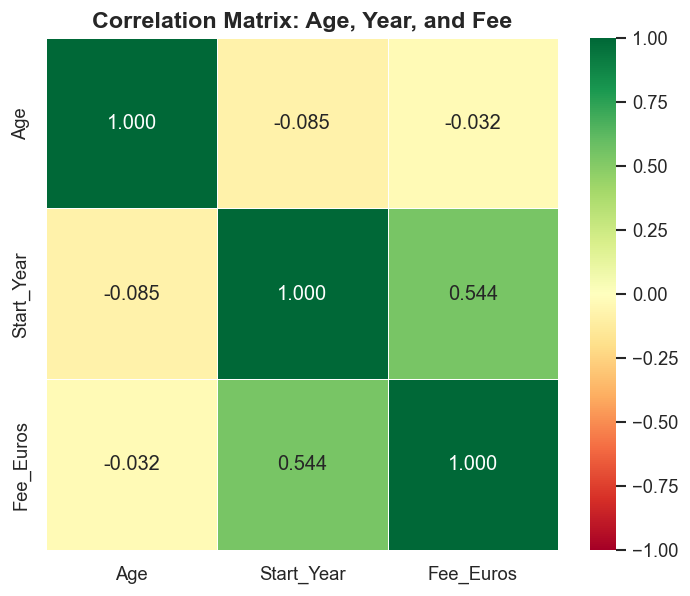

Key takeaways:
  Start_Year vs Fee_Euros : 0.544  → Strong — market era drives price
  Age        vs Fee_Euros : -0.032  → Negligible — linear model will fail


In [22]:
corr_matrix = df[["Age", "Start_Year", "Fee_Euros"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    corr_matrix,
    annot=True, fmt=".3f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    ax=ax
)

ax.set_title("Correlation Matrix: Age, Year, and Fee")
plt.tight_layout()
plt.savefig("../images/05_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("Key takeaways:")
print(f"  Start_Year vs Fee_Euros : {corr_matrix.loc['Start_Year','Fee_Euros']:.3f}  → Strong — market era drives price")
print(f"  Age        vs Fee_Euros : {corr_matrix.loc['Age','Fee_Euros']:.3f}  → Negligible — linear model will fail")

### 2.6 Average Transfer Fee by Position

**What to look for:** Whether attacking positions (Forward, Winger, Attacking Midfielder) are systematically more expensive than defensive ones. Goals and goal contributions are the most commercially monetisable output in football — shirt sales, broadcast value, marketing. The market should reflect that.

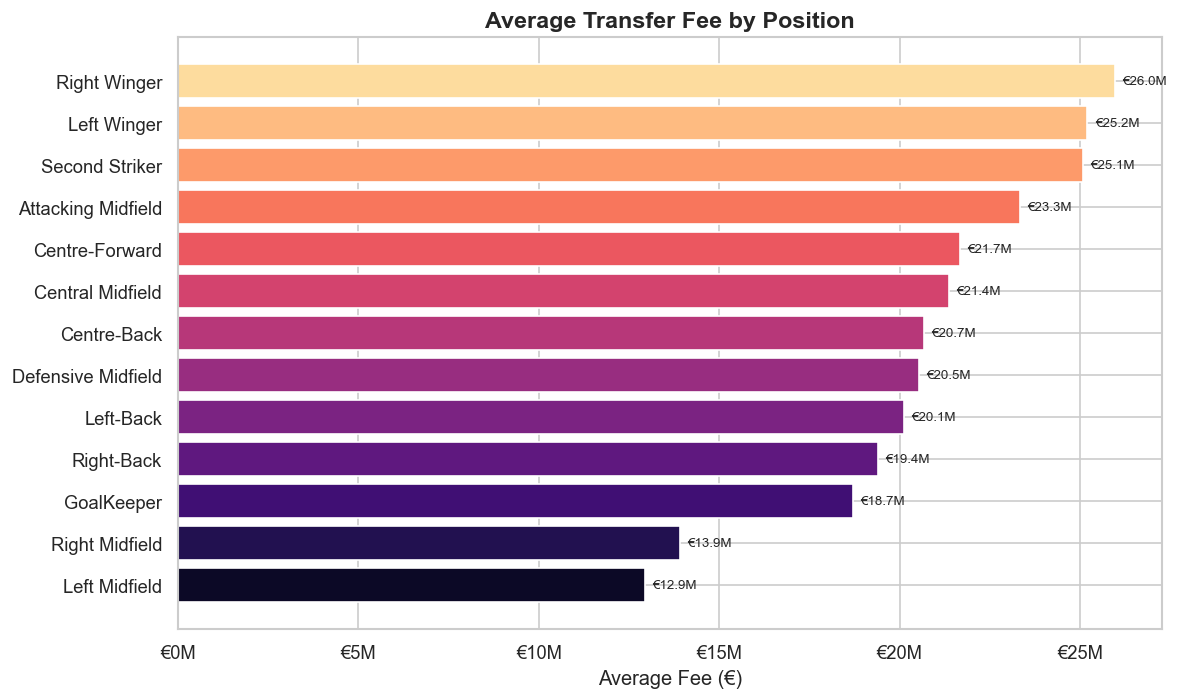

In [15]:
pos_avg = (
    df.groupby("Position")["Fee_Euros"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(pos_avg.index[::-1], pos_avg.values[::-1],
               color=sns.color_palette("magma", len(pos_avg)))

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1e6:.0f}M"))
ax.set_title("Average Transfer Fee by Position")
ax.set_xlabel("Average Fee (€)")

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2e6, bar.get_y() + bar.get_height()/2,
            f"€{width/1e6:.1f}M", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../images/06_fee_by_position.png", bbox_inches="tight")
plt.show()

### 2.7 Domestic vs. International Transfer Premium

**What to look for:** Whether cross-border transfers (player moves from one league to another) command a consistent price premium over within-league transfers. Even a modest gap, if consistent across 2,600 records, is a real structural signal worth capturing as a feature.

The boolean check `From_League != To_League` is evaluated row by row across the entire DataFrame in a single operation — no loop required. This is one of the core efficiencies of working with pandas.

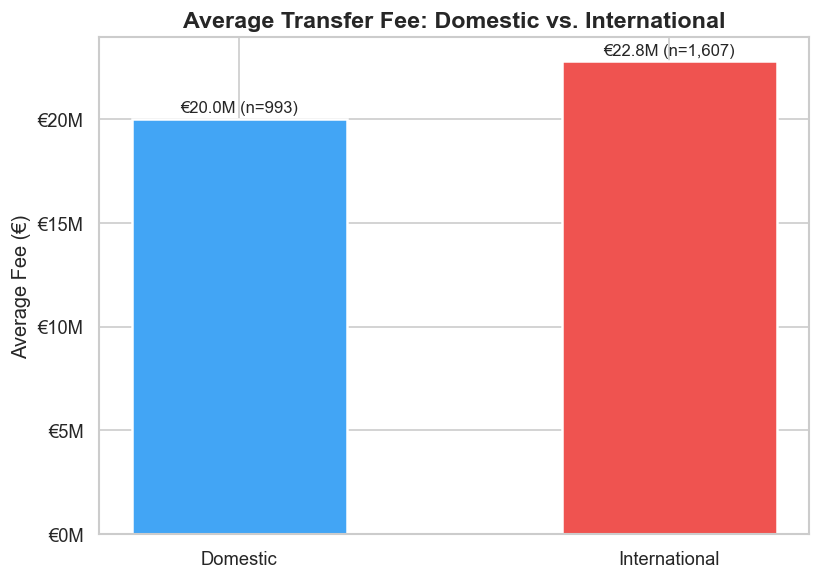

International average : €22.80M
Domestic average      : €20.02M
Export premium        : €2.78M


In [14]:
# Map each league to its country (Dataset-Specific Spelling)
league_country = {
    # --- Top 5 European Leagues ---
    "Premier League"             : "England",
    "LaLiga"                     : "Spain",      
    "Serie A"                    : "Italy",
    "Bundesliga"                 : "Germany",
    "Ligue 1"                    : "France",

    # --- 2nd Tier European Leagues ---
    "EFL Championship"           : "England",
    "LaLiga2"                    : "Spain",
    "Serie B"                    : "Italy",
    "2. Bundesliga"              : "Germany",
    "Ligue 2"                    : "France",

    # --- Other Major European Leagues ---
    "Liga Portugal"              : "Portugal",   
    "Eredivisie"                 : "Netherlands",
    "Jupiler Pro League"         : "Belgium",
    "Süper Lig"                  : "Turkey",     
    "Premier Liga Russia"        : "Russia",
    "Scottish Premiership"       : "Scotland",
    "Super League 1"             : "Greece",
    "Ukrainian Premier League"   : "Ukraine",
    "Bundesliga (Austria)"       : "Austria",
    "Super League"               : "Switzerland",
    "Superliga"                  : "Denmark",
    "Eliteserien"                : "Norway",
    "Allsvenskan"                : "Sweden",

    # --- South American Leagues ---
    "Brasileiro Série A"         : "Brazil",     
    "Brasileiro Série B"         : "Brazil",
    "Liga Profesional Argentina" : "Argentina",  
    "Categoría Primera A"        : "Colombia",
    "Liga Pro"                   : "Ecuador",
    "Primera División"           : "Uruguay",

    # --- North & Central American Leagues ---
    "Major League Soccer"        : "USA",
    "Liga MX"                    : "Mexico",

    # --- Asian & Middle Eastern Leagues ---
    "Saudi Pro League"           : "Saudi Arabia",
    "Chinese Super League"       : "China",
    "Qatar Stars League"         : "Qatar",
    "J1 League"                  : "Japan",
    "K League 1"                 : "South Korea",
    "UAE Pro League"             : "United Arab Emirates",
    
    # --- Other Notable Leagues ---
    "A-League Men"               : "Australia",
    "DStv Premiership"           : "South Africa"
}

df["From_Country"] = df["From_League"].map(league_country)
df["To_Country"]   = df["To_League"].map(league_country)

# Flag: 1 if countries differ (or either is unmapped — treat as international)
df["is_international"] = (df["From_Country"] != df["To_Country"])

type_avg = df.groupby("is_international")["Fee_Euros"].mean()
type_counts = df.groupby("is_international")["Fee_Euros"].count()

fig, ax = plt.subplots(figsize=(7, 5))

labels = ["Domestic", "International"]
values = [type_avg[False], type_avg[True]]
counts = [type_counts[False], type_counts[True]]
colors = ["#42A5F5", "#EF5350"]

bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor="white", linewidth=1.5)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1e6:.0f}M"))
ax.set_title("Average Transfer Fee: Domestic vs. International")
ax.set_ylabel("Average Fee (€)")

for bar, val, count in zip(bars, values, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3e6,
            f"€{val/1e6:.1f}M (n={count:,})", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../images/07_domestic_vs_international.png", bbox_inches="tight")
plt.show()

premium = type_avg[True] - type_avg[False]
print(f"International average : €{type_avg[True]/1e6:.2f}M")
print(f"Domestic average      : €{type_avg[False]/1e6:.2f}M")
print(f"Export premium        : €{premium/1e6:.2f}M")

---
## Phase 3 — Feature Engineering

**Goal:** Translate the cleaned data into a format a machine learning model can actually use.

ML models only understand numbers. They cannot process the string `"Premier League"` or `"Centre-Forward"`. Every text column that contains a real signal needs to be encoded as a number that preserves that signal's meaning.

Features being created:
| Feature | Type | Rationale from EDA |
|---|---|---|
| `Pos_Number` | Ordinal int | Position premium confirmed in 2.6 |
| `Inflation_Factor` | Float multiplier | Strong year correlation (0.54) means raw fees across eras aren't comparable |
| `Adjusted_Fee` | Float | Inflation-corrected fee — the fair comparison target |
| `is_international` | Binary (0/1) | Export premium confirmed in 2.7 |
| `To_League_Rank` | Ordinal int | Wealth hierarchy confirmed in 2.4 |
| `Log_Adjusted_Fee` | Float | Log transform needed due to right-skew confirmed in 2.1 |

### 3.1 Positional Encoding — Traditional Shirt Numbers

A Python dictionary acts as a lookup table. `df["Position"].map(pos_map)` replaces every position string with its corresponding number in one vectorized operation. The shirt number scheme is chosen deliberately: it creates an ordinal "attacking threat" spectrum (1 = goalkeeper, 9 = centre-forward) that reflects genuine football logic, not an arbitrary assignment.

In [13]:
df = pd.read_csv("../data/processed_transfer_data.csv")

# Map positions to traditional shirt numbers
pos_map = {
    "GoalKeeper"        : 1,
    "Right-Back"        : 2,
    "Left-Back"         : 3,
    "Centre-Back"       : 4,
    "Defensive Midfield": 6,
    "Central Midfield"  : 8,
    "Left Midfield"     : 7,
    "Right Midfield"    : 7,
    "Attacking Midfield": 10,
    "Left Winger"       : 11,
    "Right Winger"      : 11,
    "Second Striker"    : 10,
    "Centre-Forward"    : 9,
}

df["Pos_Number"] = df["Position"].map(pos_map)

unmapped = df["Pos_Number"].isnull().sum()
print(f"Unmapped positions: {unmapped}")
if unmapped > 0:
    print(df[df["Pos_Number"].isnull()]["Position"].value_counts())

df[["Player", "Position", "Pos_Number"]].head(8)

Unmapped positions: 0


,Player,Position,Pos_Number
0,Luís Figo,Right Winger,11
1,Hernán Crespo,Centre-Forward,9
2,Gabriel Batistuta,Centre-Forward,9
3,Nicolas Anelka,Centre-Forward,9
4,Marc Overmars,Left Winger,11
5,Rio Ferdinand,Centre-Back,4
6,Savo Milosevic,Centre-Forward,9
7,Flávio Conceição,Central Midfield,8


### 3.2 Inflation Adjustment — Making Eras Comparable

A €50M transfer in 2005 and a €50M transfer in 2024 are not economically equivalent. Without adjustment, the model would treat them identically despite the market being completely different.

**Method:** Calculate the mean fee for each season year. Use the most recent season as the base. For every transfer, compute how much more expensive today's market is relative to that transfer's year, and multiply the fee by that factor.

This is a relative, data-driven inflation index — no external CPI (Cost Price Inflation) data required.

In [19]:
# Mean fee per year (the "price level" of each season)
yearly_means = df.groupby("Start_Year")["Fee_Euros"].mean()

# Most recent year is the reference point
base_mean = yearly_means.iloc[-1]

# Inflation factor = how much more expensive is today vs. that year
df["Inflation_Factor"] = df["Start_Year"].map(lambda yr: base_mean / yearly_means[yr])
df["Adjusted_Fee"]     = df["Fee_Euros"] * df["Inflation_Factor"]

print(f"Base year mean (most recent season): €{base_mean/1e6:.2f}M")
print()

# Show how factors differ across eras
sample_years = yearly_means.index
print("Inflation factors for sample years:")
for yr in sample_years:
    factor = base_mean / yearly_means[yr]
    print(f"  {yr}: ×{factor:.2f}  (original mean €{yearly_means[yr]/1e6:.1f}M)")

Base year mean (most recent season): €43.79M

Inflation factors for sample years:
  2000: ×3.07  (original mean €14.3M)
  2001: ×2.76  (original mean €15.8M)
  2002: ×4.56  (original mean €9.6M)
  2003: ×5.11  (original mean €8.6M)
  2004: ×4.36  (original mean €10.0M)
  2005: ×4.69  (original mean €9.3M)
  2006: ×4.33  (original mean €10.1M)
  2007: ×3.22  (original mean €13.6M)
  2008: ×3.20  (original mean €13.7M)
  2009: ×2.92  (original mean €15.0M)
  2010: ×3.25  (original mean €13.5M)
  2011: ×3.16  (original mean €13.9M)
  2012: ×3.02  (original mean €14.5M)
  2013: ×2.21  (original mean €19.9M)
  2014: ×2.27  (original mean €19.3M)
  2015: ×1.97  (original mean €22.2M)
  2016: ×1.65  (original mean €26.5M)
  2017: ×1.29  (original mean €34.1M)
  2018: ×1.39  (original mean €31.6M)
  2019: ×1.18  (original mean €37.1M)
  2020: ×1.62  (original mean €27.1M)
  2021: ×1.64  (original mean €26.7M)
  2022: ×1.23  (original mean €35.6M)
  2023: ×1.03  (original mean €42.7M)
  2024: ×

### 3.3 League Tier Ranking and International Flag

**League rank:** Rather than hardcoding tier labels based on football opinion, we derive prestige empirically from the data itself. The league that historically receives the most expensive transfers gets rank 1. This is objective and reproducible.

**International flag:** Converting the boolean `is_international` to an integer (0/1) is necessary because scikit-learn models expect numeric arrays, not Python booleans.

In [33]:
# Map each league to its country (Dataset-Specific Spelling)
league_country = {
    # --- Top 5 European Leagues ---
    "Premier League"             : "England",
    "LaLiga"                     : "Spain",      
    "Serie A"                    : "Italy",
    "Bundesliga"                 : "Germany",
    "Ligue 1"                    : "France",

    # --- 2nd Tier European Leagues ---
    "EFL Championship"           : "England",
    "LaLiga2"                    : "Spain",
    "Serie B"                    : "Italy",
    "2. Bundesliga"              : "Germany",
    "Ligue 2"                    : "France",

    # --- Other Major European Leagues ---
    "Liga Portugal"              : "Portugal",   
    "Eredivisie"                 : "Netherlands",
    "Jupiler Pro League"         : "Belgium",
    "Süper Lig"                  : "Turkey",     
    "Premier Liga Russia"        : "Russia",
    "Scottish Premiership"       : "Scotland",
    "Super League 1"             : "Greece",
    "Ukrainian Premier League"   : "Ukraine",
    "Bundesliga (Austria)"       : "Austria",
    "Super League"               : "Switzerland",
    "Superliga"                  : "Denmark",
    "Eliteserien"                : "Norway",
    "Allsvenskan"                : "Sweden",

    # --- South American Leagues ---
    "Brasileiro Série A"         : "Brazil",     
    "Brasileiro Série B"         : "Brazil",
    "Liga Profesional Argentina" : "Argentina",  
    "Categoría Primera A"        : "Colombia",
    "Liga Pro"                   : "Ecuador",
    "Primera División"           : "Uruguay",

    # --- North & Central American Leagues ---
    "Major League Soccer"        : "USA",
    "Liga MX"                    : "Mexico",

    # --- Asian & Middle Eastern Leagues ---
    "Saudi Pro League"           : "Saudi Arabia",
    "Chinese Super League"       : "China",
    "Qatar Stars League"         : "Qatar",
    "J1 League"                  : "Japan",
    "K League 1"                 : "South Korea",
    "UAE Pro League"             : "United Arab Emirates",
    
    # --- Other Notable Leagues ---
    "A-League Men"               : "Australia",
    "DStv Premiership"           : "South Africa"
}

df["From_Country"] = df["From_League"].map(league_country)
df["To_Country"]   = df["To_League"].map(league_country)

# Flag: 1 if countries differ (or either is unmapped — treat as international)
df["is_international"] = (df["From_Country"] != df["To_Country"]).astype(int)

# Rank leagues by average incoming transfer fee (empirical prestige)
league_avg   = df.groupby("To_League")["Fee_Euros"].mean().sort_values(ascending=False)
league_rank  = {league: rank + 1 for rank, league in enumerate(league_avg.index)}
df["To_League_Rank"] = df["To_League"].map(league_rank)

print("Top 10 leagues by rank (1 = highest average spend):")
for league, rank in list(league_rank.items())[:10]:
    print(f"  Rank {rank:>2}  |  {league}  (avg €{league_avg[league]/1e6:.1f}M)")

Top 10 leagues by rank (1 = highest average spend):
  Rank  1  |  Saudi Pro League  (avg €34.4M)
  Rank  2  |  Premier League  (avg €25.3M)
  Rank  3  |  Jupiler Pro League  (avg €25.0M)
  Rank  4  |  Chinese Super League  (avg €24.2M)
  Rank  5  |  LaLiga  (avg €23.6M)
  Rank  6  |  Ligue 1  (avg €21.3M)
  Rank  7  |  Bundesliga  (avg €19.8M)
  Rank  8  |  Serie A  (avg €18.6M)
  Rank  9  |  Brasileiro Série A  (avg €16.0M)
  Rank 10  |  Qatar Stars League  (avg €15.2M)


### 3.4 Log-Transform the Target and Save the ML-Ready File

The prediction target (`Adjusted_Fee`) is right-skewed even after inflation adjustment. We apply `log1p` to create `Log_Adjusted_Fee` — the actual column the model will predict. Training on log-fees means the model thinks in proportional terms (a 10% error on a €10M transfer and a 10% error on a €100M transfer are treated equivalently), which produces more stable training.

In [35]:
# Log-transform the prediction target
df["Log_Adjusted_Fee"] = np.log1p(df["Adjusted_Fee"])

# Save ML-ready file
df.to_csv("../data/ml_ready_transfer_data.csv", index=False)

print("Feature engineering complete. Columns in ml_ready_transfer_data.csv:")
print(list(df.columns))
print()
print("Sample of new features:")
df[["Player", "Position", "Pos_Number", "Fee_Euros", "Adjusted_Fee",
    "Inflation_Factor", "To_League_Rank", "is_international", "Log_Adjusted_Fee"]].head(6)

Feature engineering complete. Columns in ml_ready_transfer_data.csv:
['Season', 'Player', 'Position', 'Age', 'Nationality', 'From_League', 'From_Club', 'To_League', 'To_Club', 'Fee_Euros', 'Loan_Fee', 'Start_Year', 'End_Year', 'Pos_Number', 'Inflation_Factor', 'Adjusted_Fee', 'From_Country', 'To_Country', 'is_international', 'To_League_Rank', 'Log_Adjusted_Fee']

Sample of new features:


,Player,Position,Pos_Number,Fee_Euros,Adjusted_Fee,Inflation_Factor,To_League_Rank,is_international,Log_Adjusted_Fee
0,Luís Figo,Right Winger,11,60000000,1.842387e+08,3.070644,5,0,19.031742
1,Hernán Crespo,Centre-Forward,9,56810000,1.744433e+08,3.070644,8,0,18.977110
2,Gabriel Batistuta,Centre-Forward,9,36150000,1.110038e+08,3.070644,8,0,18.525075
3,Nicolas Anelka,Centre-Forward,9,34500000,1.059372e+08,3.070644,6,1,18.478357
4,Marc Overmars,Left Winger,11,29300000,8.996987e+07,3.070644,5,1,18.314985
5,Rio Ferdinand,Centre-Back,4,26000000,7.983675e+07,3.070644,2,0,18.195494


---
## Phase 4 — Machine Learning

**Goal:** Build a model to predict transfer fees, then interrogate what it learned and what it couldn't learn.

**Why Random Forest, not Linear Regression?**
EDA proved that age and fee have a -0.03 correlation. Linear regression assumes a straight-line relationship between inputs and the target. A flat correlation means no such line exists. Random Forest avoids this assumption entirely — it builds hundreds of decision trees that can capture curved, conditional "if/then" relationships (e.g., *if age < 21 AND league = top tier → predict premium*).

**Features used:**
| Feature | What it represents |
|---|---|
| `Age` | Player age at transfer |
| `Pos_Number` | Encoded position (1–11 attacking spectrum) |
| `To_League_Rank` | Destination league prestige (lower rank = higher spend) |
| `Start_Year` | Season year (captures market inflation trend) |
| `is_international` | Whether the player crossed leagues (export premium) |

### 4.1 Define Features, Split Data, Train the Model

**80/20 split:** The model sees 80% of records during training. The remaining 20% is hidden and only used to test predictions. This prevents the model from simply memorising answers rather than learning patterns.

`random_state=42` seeds the random number generator — ensures the same 80/20 division every time you run the notebook, making results reproducible.

In [21]:
df = pd.read_csv("../data/ml_ready_transfer_data.csv")

# Drop rows where feature engineering produced nulls (unmapped positions, etc.)
df_ml = df.dropna(subset=["Pos_Number", "To_League_Rank", "Log_Adjusted_Fee"]).copy()

FEATURES = ["Age", "Pos_Number", "To_League_Rank", "Start_Year", "is_international"]
TARGET   = "Log_Adjusted_Fee"

X = df_ml[FEATURES]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]:,} records")
print(f"Test set     : {X_test.shape[0]:,} records")
print(f"Features     : {FEATURES}")

# Train
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print()
print("Model trained.")

Training set : 2,080 records
Test set     : 520 records
Features     : ['Age', 'Pos_Number', 'To_League_Rank', 'Start_Year', 'is_international']

Model trained.


### 4.2 Evaluate Model Performance

**R² (R-squared):** Measures what fraction of the variance in actual fees the model explains. 1.0 = perfect. 0.0 = no better than always predicting the mean. Negative = actively worse than predicting the mean.

**Interpreting a low R²:** In most projects, a low R² is a failure. Here, it is the central finding. It is mathematical proof that Age, Position, League, and Year collectively explain only a fraction of what drives a transfer fee. The unmodelled factors — remaining contract length, selling club's financial desperation, commercial hype, deadline-day dynamics — are the real drivers.

In [24]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print()

if r2 < 0:
    interpretation = "Negative — The model is entirely mis-specified and performs worse than simply guessing the average fee."
elif r2 < 0.3:
    interpretation = "Low — demographic and market features explain only a small fraction of fee variance."
elif r2 < 0.6:
    interpretation = "Moderate — features capture some signal but most variance is unexplained."
else:
    interpretation = "Strong — features explain a significant portion of fee variance."

print(f"Interpretation: {interpretation}")
print()
print("This is a finding, not a failure.")
print("It proves that football fees are driven by qualitative factors not present in this dataset.")

R² Score: -0.1711

Interpretation: Negative — The model is entirely mis-specified and performs worse than simply guessing the average fee.

This is a finding, not a failure.
It proves that football fees are driven by qualitative factors not present in this dataset.


### 4.3 Feature Importance — What Did the Model Actually Learn?

Feature importance measures how much each variable contributed to reducing prediction error across all 100 trees. The most important feature is the one the model relied on most heavily when splitting its decision trees.

**What to look for:** Whether `Start_Year` dominates all other features, confirming the correlation heatmap finding that market era is a stronger price signal than any player attribute.

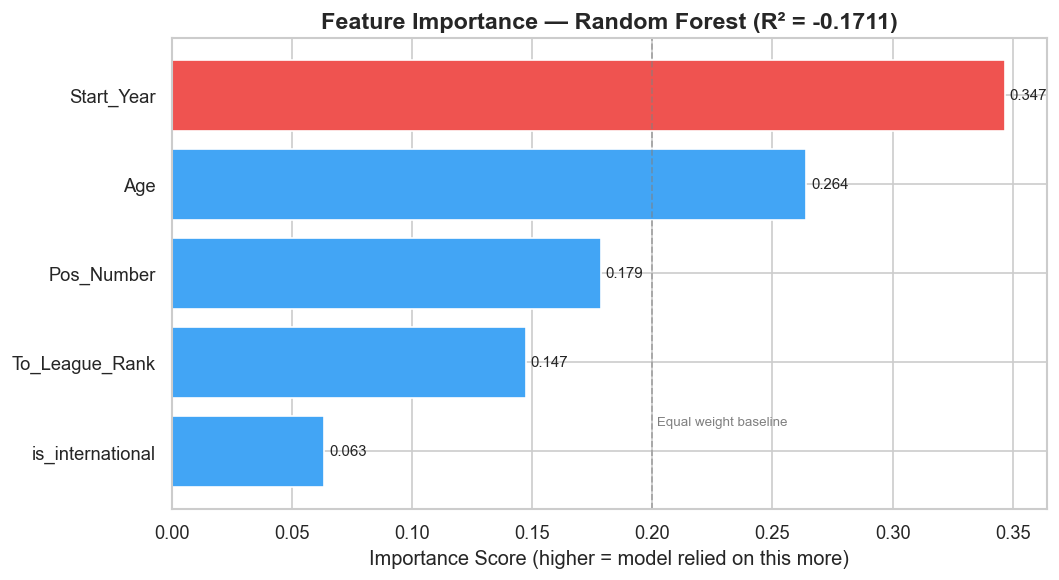

Feature importance ranking:
  Start_Year           ██████████████████████████████████ 0.3468
  Age                  ██████████████████████████ 0.2641
  Pos_Number           █████████████████ 0.1786
  To_League_Rank       ██████████████ 0.1472
  is_international     ██████ 0.0633


In [40]:
importance_df = pd.DataFrame({
    "Feature"   : FEATURES,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#EF5350" if f == "Start_Year" else "#42A5F5" for f in importance_df["Feature"]]
bars = ax.barh(importance_df["Feature"], importance_df["Importance"],
               color=colors, edgecolor="white")

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height()/2,
            f"{width:.3f}", va="center", fontsize=9)

ax.set_title(f"Feature Importance — Random Forest (R² = {r2:.4f})")
ax.set_xlabel("Importance Score (higher = model relied on this more)")
ax.axvline(1/len(FEATURES), color="grey", linestyle="--", linewidth=1, alpha=0.6)
ax.text(1/len(FEATURES) + 0.002, 0.3, "Equal weight baseline", fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("../images/08_feature_importance.png", bbox_inches="tight")
plt.show()

print("Feature importance ranking:")
for _, row in importance_df.sort_values("Importance", ascending=False).iterrows():
    bar = "█" * int(row["Importance"] * 100)
    print(f"  {row['Feature']:<20} {bar} {row['Importance']:.4f}")

### 4.4 Predicted vs. Actual Fees — Visualising Where the Model Fails

A perfect model would place every dot on the diagonal line (predicted = actual). Scatter around the line shows error. Systematic patterns in the scatter — e.g., the model consistently underpredicting very high fees — reveal structural limitations.

Note: values are in log-transformed, inflation-adjusted scale. Higher values on both axes = more expensive transfers.

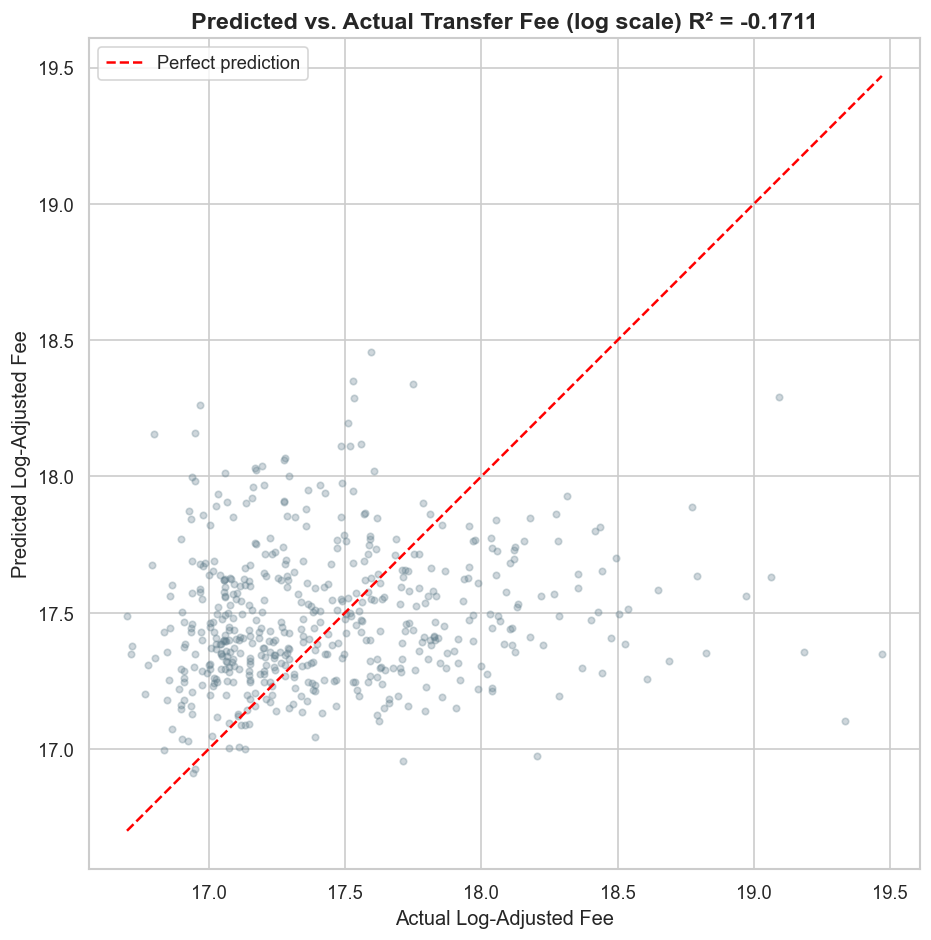

In [41]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred, alpha=0.3, s=15, color="#607D8B")

# Perfect prediction line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")

ax.set_title(f"Predicted vs. Actual Transfer Fee (log scale) R² = {r2:.4f}")
ax.set_xlabel("Actual Log-Adjusted Fee")
ax.set_ylabel("Predicted Log-Adjusted Fee")
ax.legend()
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("../images/09_predicted_vs_actual.png", bbox_inches="tight")
plt.show()

---
## Conclusion

### Summary of Findings

| Finding | Evidence |
|---|---|
| Transfer fees are right-skewed; log transform is required | Skewness dropped from ~5+ to near 0 after log1p |
| The market is bifurcating — elite transfers inflate faster than average | Mean/median divergence post-2014 |
| Age has no linear relationship with transfer fee | Pearson correlation: -0.03 |
| Market era (year) is the strongest price predictor | Correlation with fee: 0.54; top feature importance |
| League destination is the strongest structural signal | Clear wealth hierarchy in 2.4; ranked feature used in model |
| Demographic features alone cannot predict transfer fees | Low R² from fully engineered model |

### The Core Insight

The model's negative R² is not a failure — it is the most important result. It proves mathematically what football insiders know qualitatively: **transfer fees are fundamentally driven by qualitative factors that do not appear in any public dataset.** Contract length remaining, ownership desperation, commercial hype, and deadline-day dynamics account for more of the price than a player's age, position, or even the league they're moving to.

`Start_Year` being the dominant feature confirms one actionable truth: **you are buying into a market as much as you are buying a player.** The era of the transfer matters more than who the player is.

### What This Means in Practice

- **Clubs without elite broadcast revenue** cannot compete in the superstar tier and should focus strategy on feeder league pipelines (Liga Portugal, Eredivisie, EFL Championship) where the data shows deep talent supply.
- **Fee prediction models** built on demographics alone will structurally underperform. Useful predictive tools would need contract data, performance metrics, and commercial indicators.
- **For data science practice:** a model that fails informatively is more valuable than one that succeeds without explanation. The R² score is a number; the interpretation is the knowledge.